# Segmentação de Clientes por Perfil de Churn
## PRT Seguros

**Entrega:** segmentação dos clientes em grupos de perfil semelhante, com a taxa média de churn de
cada grupo — para orientar em quais perfis a PRT Seguros deve concentrar esforço de retenção.

**Importante — consistência com o modelo final:** os clusters usados aqui são **exatamente os
mesmos** já calculados dentro do pipeline de modelagem (`modelagem_caue/00_preparacao_dados.ipynb`),
que por sua vez alimentam o modelo vencedor (`modelagem_caue/25_modelo_final_vencedor.ipynb`).
Não recalculamos o K-Means aqui — carregamos os arquivos já processados, então o cluster de cada
cliente neste relatório é o mesmo número que o modelo usa internamente. Isso garante que a
segmentação de negócio e a feature usada pelo modelo preditivo contem a mesma história.

- **Algoritmo:** K-Means, **K = 6** (definido no notebook de modelagem via método do cotovelo + silhueta)
- **Base:** os 100.000 clientes de `Base_Unificada_Outer.csv` (toda a base com rótulo de churn conhecido)
- **Features usadas para formar os clusters:** 22 variáveis numéricas/binárias mais correlacionadas
  com churn (tempo de relacionamento, apólices, produtos, desconto, índice de relacionamento, NPS,
  tipo de cobertura, renda, patrimônio, engajamento digital, reclamações — a lista completa está em
  `FEATURES_CLUSTER` no notebook `00_preparacao_dados.ipynb`)


## 1. Carregar os clientes já com o cluster atribuído pelo pipeline de modelagem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PRT_NAVY, PRT_GREEN, PRT_GRAY = "#19284F", "#39694B", "#737C8A"

train = pd.read_csv("../modelagem_caue/dados_processados/train_model_ready.csv")
val = pd.read_csv("../modelagem_caue/dados_processados/val_model_ready.csv")
df = pd.concat([train, val], ignore_index=True)

df["cluster"] = df["cluster"].astype(int)
print(f"Total de clientes: {len(df):,}")
print(f"Clusters: {sorted(df['cluster'].unique())}")


Total de clientes: 100,000
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 2. Reconstruir categorias legíveis

As colunas de categoria vêm em one-hot (`tipo_cobertura_basica`, `tipo_cobertura_padrao`, ...) —
juntamos de volta numa única coluna por categoria, só para deixar o perfil fácil de ler.

In [2]:
GRUPOS_CATEGORICOS = {
    "tipo_cobertura": ["tipo_cobertura_NaN", "tipo_cobertura_basica", "tipo_cobertura_padrao", "tipo_cobertura_premium"],
    "segmento": ["segmento_Bronze", "segmento_Diamante", "segmento_NaN", "segmento_Ouro", "segmento_Prata"],
    "escolaridade": ["escolaridade_Fundamental", "escolaridade_Medio", "escolaridade_NaN", "escolaridade_Pos", "escolaridade_Superior"],
    "canal_aquisicao": ["canal_aquisicao_Agente", "canal_aquisicao_Digital", "canal_aquisicao_Indicacao", "canal_aquisicao_NaN", "canal_aquisicao_Telefone"],
    "metodo_pagamento": ["metodo_pagamento_NaN", "metodo_pagamento_boleto", "metodo_pagamento_credito", "metodo_pagamento_debito", "metodo_pagamento_pix"],
    "veiculo": ["veiculo_Carro", "veiculo_Moto", "veiculo_NaN", "veiculo_Pickup", "veiculo_SUV", "veiculo_Van"],
    "regiao": ["regiao_Centro-Oeste", "regiao_NaN", "regiao_Nordeste", "regiao_Sudeste", "regiao_Sul"],
}

for grupo, cols in GRUPOS_CATEGORICOS.items():
    df[grupo] = df[cols].idxmax(axis=1).str.replace(grupo + "_", "", regex=False)


## 3. Perfil de cada cluster — números que importam para o negócio

Média das principais variáveis + tamanho do grupo + **taxa média de churn** (a probabilidade
histórica de um cliente daquele grupo cancelar a apólice).

In [3]:
NUMERICAS_PERFIL = [
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "indice_relacionamento", "satisfacao_nps", "renda_anual", "valor_imovel",
    "idade", "score_engajamento_digital", "num_reclamacoes_12m", "num_acessos_app_mes",
]

perfil = df.groupby("cluster")[NUMERICAS_PERFIL].mean().round(1)
perfil["n_clientes"] = df.groupby("cluster").size()
perfil["pct_da_base"] = (perfil["n_clientes"] / len(df) * 100).round(1)
perfil["taxa_media_churn_pct"] = (df.groupby("cluster")["churned"].mean() * 100).round(1)
perfil["cobertura_predominante"] = df.groupby("cluster")["tipo_cobertura"].agg(lambda x: x.mode().iat[0])

perfil = perfil.sort_values("taxa_media_churn_pct", ascending=False)
perfil


,tempo_cliente_dias,num_apolices_ativas,num_produtos_contratados,indice_relacionamento,satisfacao_nps,renda_anual,valor_imovel,idade,score_engajamento_digital,num_reclamacoes_12m,num_acessos_app_mes,n_clientes,pct_da_base,taxa_media_churn_pct,cobertura_predominante
cluster,,,,,,,,,,,,,,,
3,1462.6,3.5,1.2,52.6,5.9,66590.4,261059.8,40.6,54.6,0.9,10.9,29107,29.1,21.7,basica
5,2096.9,2.6,2.0,44.7,4.3,76750.5,287925.5,43.0,52.1,1.1,10.4,5610,5.6,18.5,basica
1,1720.4,2.8,1.5,48.7,5.6,69469.6,271580.6,41.9,54.5,1.0,10.9,19610,19.6,16.9,basica
0,2413.6,2.3,2.5,54.7,6.4,81054.1,301918.0,43.6,50.1,0.9,9.9,1597,1.6,10.1,padrao
4,3131.8,1.5,3.1,59.2,6.9,92130.9,336120.3,46.3,47.1,0.8,9.4,22859,22.9,3.1,padrao
2,3401.2,1.3,3.8,58.2,6.9,93323.6,339030.4,46.7,47.6,0.8,9.5,21217,21.2,2.6,premium


## 4. Gráfico — taxa de churn por cluster (ordenado do maior para o menor risco)

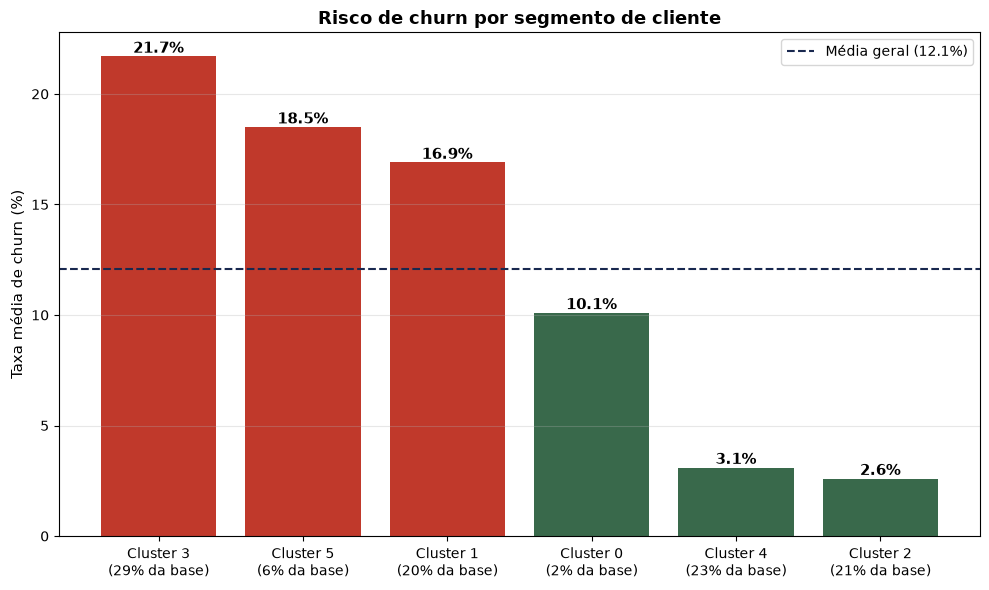

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = [PRT_GREEN if v < perfil["taxa_media_churn_pct"].mean() else "#c0392b" for v in perfil["taxa_media_churn_pct"]]
barras = ax.bar(
    [f"Cluster {c}\n({perfil.loc[c, 'pct_da_base']:.0f}% da base)" for c in perfil.index],
    perfil["taxa_media_churn_pct"], color=cores,
)
ax.axhline(y=df["churned"].mean() * 100, color=PRT_NAVY, linestyle="--",
           label=f"Média geral ({df['churned'].mean()*100:.1f}%)")
for barra in barras:
    altura = barra.get_height()
    ax.annotate(f"{altura:.1f}%", (barra.get_x() + barra.get_width() / 2, altura),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Taxa média de churn (%)", fontsize=11)
ax.set_title("Risco de churn por segmento de cliente", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 5. Visualização 2D dos clusters (PCA)

Só para fins de visualização — reduz as 22 variáveis usadas na clusterização a 2 eixos que
preservam o máximo de variância possível.

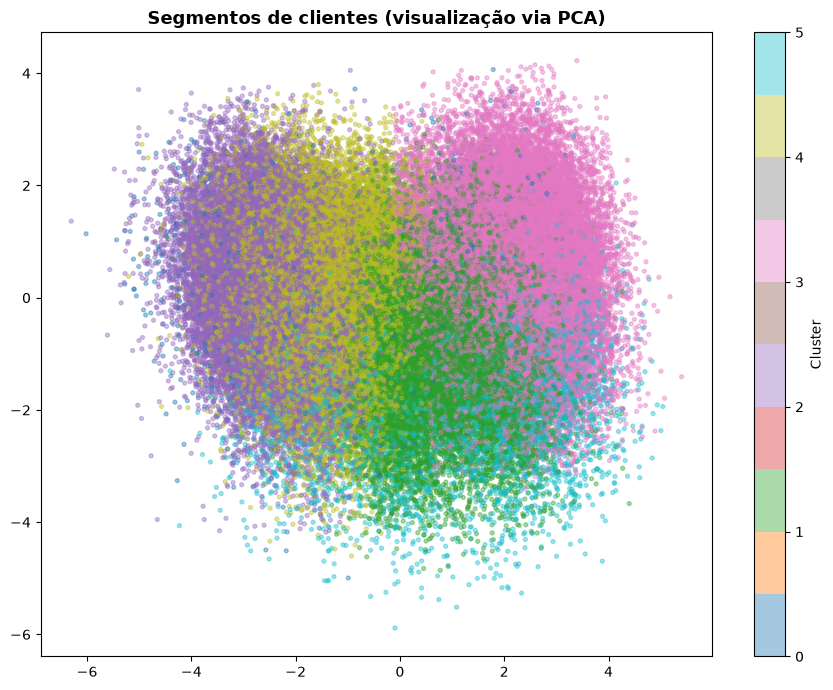

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

FEATURES_CLUSTER = [
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "desconto_aplicado_pct", "indice_relacionamento", "satisfacao_nps",
    "tipo_cobertura_basica", "estado_civil", "tipo_cobertura_premium",
    "tem_filhos", "renda_anual", "qtd_dependentes", "valor_imovel",
    "valor_cobertura_total", "idade", "score_engajamento_digital",
    "pagamento_em_dia", "num_reclamacoes_12m", "num_acessos_app_mes",
    "possui_imovel", "tipo_cobertura_padrao",
]

X = SimpleImputer(strategy="median").fit_transform(df[FEATURES_CLUSTER])
X_scaled = StandardScaler().fit_transform(X)
coords = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="tab10", alpha=0.4, s=8)
ax.set_title("Segmentos de clientes (visualização via PCA)", fontsize=13, fontweight="bold")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


## 6. Perfil descritivo de cada cluster — para levar ao cliente

Interpretação em linguagem de negócio, baseada nos números da seção 3 (ordenado do maior para o
menor risco de churn).

| Cluster | % da base | Taxa de churn | Perfil |
|---|---|---|---|
| **3** | 29,1% (maior grupo) | **21,7%** ⚠️ | Clientes **mais novos** (tempo médio ~4 anos), **poucos produtos** (1,2), **cobertura básica** predominante, renda mais baixa da base (R$ 66,6k). Maior grupo E maior risco — prioridade #1 de retenção. |
| **5** | 5,6% | **18,5%** ⚠️ | **Menor satisfação (NPS 4,3) e menor índice de relacionamento (44,7)** de todos os clusters — sinal de insatisfação ativa, não só de tempo de casa curto. |
| **1** | 19,6% | **16,9%** ⚠️ | Perfil parecido ao cluster 3 (cobertura básica, poucos produtos), um pouco mais estabelecido (tempo médio ~4,7 anos). |
| **0** | 1,6% (menor grupo) | 10,1% | Grupo pequeno e misto (cobertura padrão/premium, indicadores medianos) — baixo volume, risco moderado. |
| **4** | 22,9% | 3,1% ✅ | Clientes fiéis (~8,6 anos de relacionamento), **cobertura padrão** predominante, mais produtos (3,1), renda alta (R$ 92,1k), bom relacionamento e NPS. |
| **2** | 21,2% | 2,6% ✅ | **Quase 100% cobertura premium**, clientes mais antigos (~9,3 anos), mais produtos (3,8) e maior renda (R$ 93,3k) de toda a base — segmento mais saudável e rentável. |

**Insight central para a estratégia de retenção:** os clusters **3, 5 e 1** somam **54,3% da base**
e concentram todo o risco de churn acima da média — todos compartilham cobertura básica/poucos
produtos/tempo de relacionamento mais curto. Os clusters **2 e 4** (44% da base) são o oposto:
clientes antigos, com cobertura padrão/premium e múltiplos produtos, com churn abaixo de 3,1%.

> Variáveis como escolaridade, canal de aquisição, método de pagamento, veículo e região **não
> diferenciam os clusters** (ficam com a mesma proporção em todos os grupos) — não fizeram parte das
> variáveis usadas para formar os clusters, e por isso não devem ser usadas como critério de
> segmentação para ações de retenção.
